# Classification Track (Part A) -- UrbanGlide Incident Type Classification

**Goal:** classify micro-mobility incidents (`Normal`, `Hard_Braking`, `Battery_Critical`, `Mechanical_Fault`, `Improper_Parking`) using the 5 Part-A algorithms required for Review 1. Part B (5 more algorithms) is added in Review 2.

**Owner:** Person B, both reviews.

---

### Section 0 -- Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report,
                              roc_auc_score)

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 95
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

print("Libraries loaded.")


Libraries loaded.


### Step 1.1 -- Dataset loading & audit

For a classification problem, the audit has to include the class distribution, not just feature dtypes -- it determines every metric choice for the rest of the notebook.

In [2]:
clf_file = "../data/urbanglide_classification_incident.csv"
df_clf = pd.read_csv(clf_file)

print("=" * 65)
print("  CLASSIFICATION DATASET AUDIT")
print("=" * 65)
print(f"Shape: {df_clf.shape[0]:,} rows x {df_clf.shape[1]} columns\n")
print("Column dtypes:")
for col, dt in df_clf.dtypes.items():
    print(f"  {col:<30} {dt}")

mv = df_clf.isnull().sum()
miss = pd.DataFrame({'Missing Count': mv, 'Missing %': (mv/len(df_clf)*100).round(2)})[mv > 0]
print("\nMissing value profile:")
print(miss.to_string() if len(miss) else "  None")

print("\nTarget ('incident_type') class counts:")
print(df_clf['incident_type'].value_counts().to_string())


  CLASSIFICATION DATASET AUDIT
Shape: 12,030 rows x 14 columns

Column dtypes:
  ride_id                        int64
  vehicle_type                   str
  distance_km                    float64
  duration_min                   float64
  avg_speed_kmph                 float64
  max_speed_kmph                 float64
  battery_start_percent          float64
  battery_end_percent            float64
  sudden_stop_count              int64
  terrain_elevation_gain_m       float64
  temperature_c                  float64
  rider_age_group                str
  gps_signal_quality             float64
  incident_type                  str

Missing value profile:
                    Missing Count  Missing %
rider_age_group               108       0.90
gps_signal_quality            107       0.89

Target ('incident_type') class counts:
incident_type
Normal              6243
Hard_Braking        2863
Battery_Critical    1257
Mechanical_Fault     963
Improper_Parking     704


#### Output analysis

12,030 rows, missing values isolated to `rider_age_group`, `gps_signal_quality` at under 1% each. The class counts already hint at imbalance -- quantified properly in the next cell.

### Step 1.2 -- Class imbalance

The single most consequential cell in this track. If one class dominates, accuracy alone is a misleading metric and the train/test split needs to be stratified.

incident_type
Normal              51.9
Hard_Braking        23.8
Battery_Critical    10.4
Mechanical_Fault     8.0
Improper_Parking     5.9


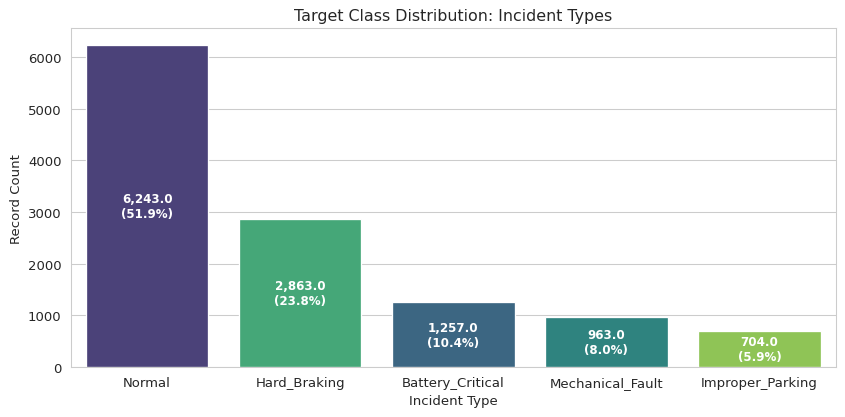

In [3]:
plt.figure(figsize=(9, 4.5))
order = df_clf['incident_type'].value_counts().index
ax = sns.countplot(data=df_clf, x='incident_type', order=order, hue='incident_type', legend=False, palette='viridis')
plt.title("Target Class Distribution: Incident Types")
plt.xlabel("Incident Type"); plt.ylabel("Record Count")

total = len(df_clf)
for p in ax.patches:
    h = p.get_height()
    pct = f"{100*h/total:.1f}%"
    ax.annotate(f"{h:,}\n({pct})", (p.get_x()+p.get_width()/2, h/2), ha='center', va='center',
                fontsize=9, color='white', weight='bold')
plt.tight_layout()
plt.show()

class_pcts = (df_clf['incident_type'].value_counts(normalize=True) * 100).round(1)
print(class_pcts.to_string())


#### Output analysis

`Normal` alone accounts for **51.9%** of rows. A model that predicts `Normal` for every single ride scores 51.9% accuracy while being completely useless -- which is why macro F1 is reported alongside accuracy for every model below, and why the split uses `stratify=y`. The smallest class (`Improper_Parking`, 5.9%) has too few examples for any algorithm to learn it reliably; expect that class's recall to be the weakest number in every result this track produces.

### Step 1.3 -- Per-feature distributions

All ten numeric predictors -- the gap the original EDA draft left for this dataset.

Plotted 10 numeric features.


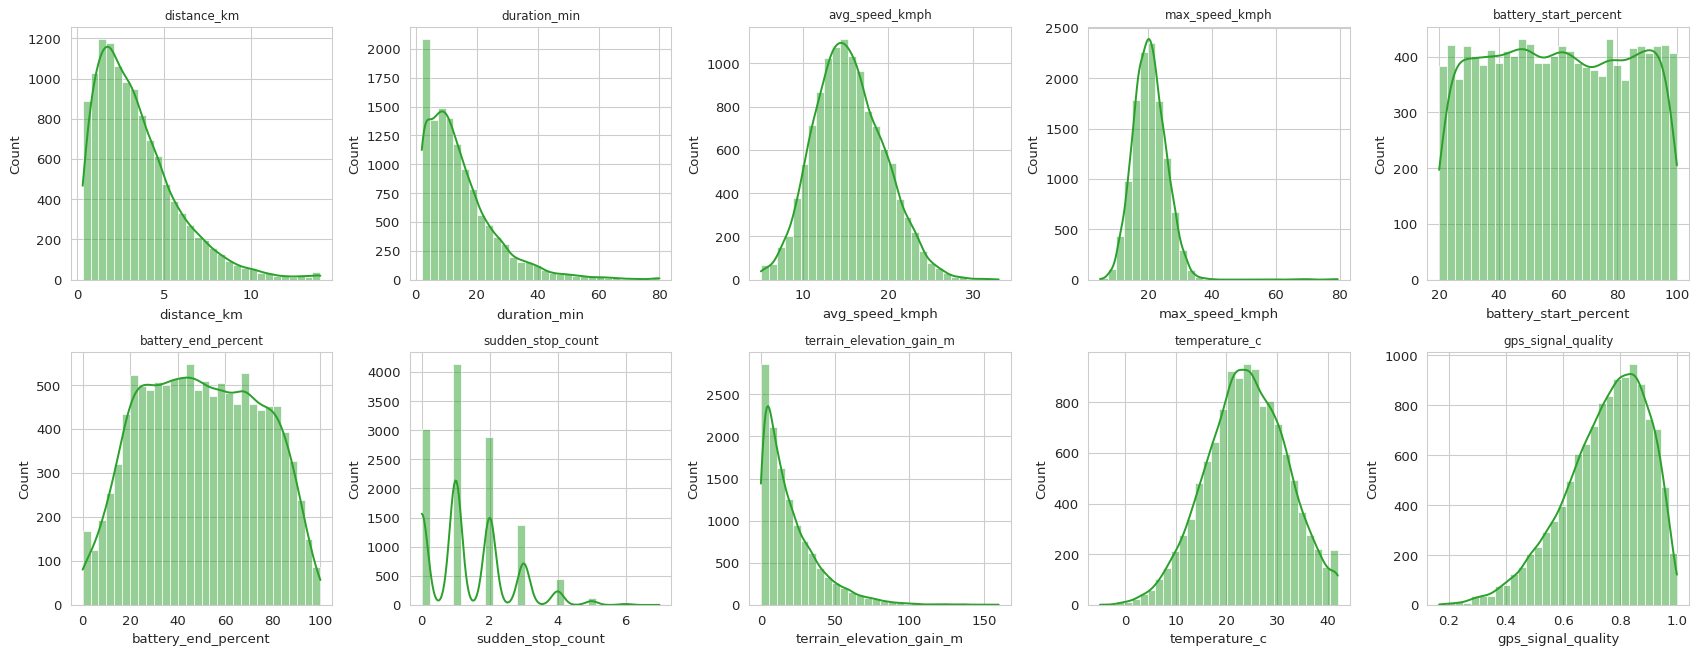

In [4]:
num_cols_clf = ['distance_km', 'duration_min', 'avg_speed_kmph', 'max_speed_kmph',
                'battery_start_percent', 'battery_end_percent', 'sudden_stop_count',
                'terrain_elevation_gain_m', 'temperature_c', 'gps_signal_quality']

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
for idx, col in enumerate(num_cols_clf):
    sns.histplot(df_clf[col].dropna(), kde=True, ax=axes[idx], color='#2ca02c', bins=30)
    axes[idx].set_title(col, fontsize=9)
plt.tight_layout()
plt.show()
print(f"Plotted {len(num_cols_clf)} numeric features.")


#### Output analysis

`sudden_stop_count` is heavily right-skewed with a spike at zero -- most rides have no hard stops at all, which is exactly why a handful of hard stops stands out as a signal rather than getting lost in noise. Battery start/end percentages spread fairly evenly across their range.

### Step 1.4 -- Categorical breakdowns

`vehicle_type` and `rider_age_group` against incident type, to check whether either category shifts the class mix.

Categorical breakdowns plotted.


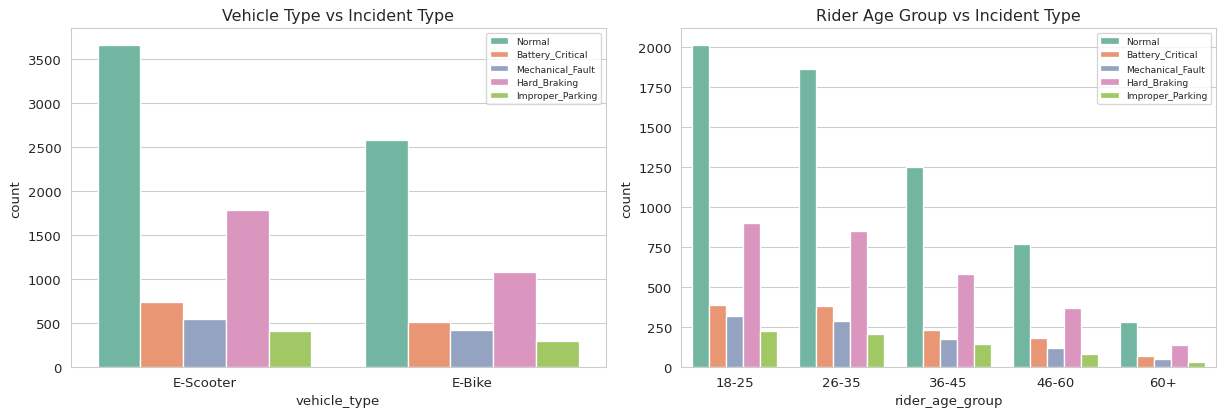

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.countplot(data=df_clf, x='vehicle_type', hue='incident_type', ax=axes[0], palette='Set2')
axes[0].set_title("Vehicle Type vs Incident Type")
axes[0].legend(fontsize=7)

age_order = sorted(df_clf['rider_age_group'].dropna().unique())
sns.countplot(data=df_clf, x='rider_age_group', hue='incident_type', order=age_order, ax=axes[1], palette='Set2')
axes[1].set_title("Rider Age Group vs Incident Type")
axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()
print("Categorical breakdowns plotted.")


#### Output analysis

Neither category visibly shifts the incident-type mix on its own -- both vehicle types and every age group show roughly the same proportions across incident classes. They're kept in the model in case they interact with other features, but neither looks like a standalone driver.